In [1]:
import numpy as np
import os
import glob 
import time 
import pandas as pd
import shutil
import re
import mdtraj as md
import MDAnalysis as mda
import pickle
import pickle as p 
import csv
import sys
import subprocess
import xml.etree.ElementTree as ET
import requests
import concurrent.futures
import multiprocessing
import nglview as nv
import h5py
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
import html
import biobox as bb
import tempfile
import matplotlib.pyplot as plt
import molearn
import torch
import glob as glob
import MDAnalysis.analysis.rms as rms
import seaborn as sns
import pickle
import networkx as nx
sys.path.insert(0, os.path.join(os.path.abspath(os.pardir),'src'))

from Bio import PDB
from tqdm import tqdm
from time import time as t
from urllib.request import urlretrieve as download
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.Blast.Applications import NcbipsiblastCommandline
from collections import defaultdict
from Bio.PDB import PPBuilder
from Bio.SeqUtils import seq1
from modeller import *
from modeller.automodel import *
from Bio.PDB import PDBParser
from MDAnalysis.analysis import align
from mpi4py import MPI
from glob import glob
from pprint import pprint as pp
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from glob import glob as g
from tqdm.notebook import tqdm
from collections import Counter
from matplotlib.ticker import FuncFormatter
from collections import defaultdict
from pymol import cmd
from scipy.interpolate import interp1d
from mpl_toolkits import mplot3d
from scipy import stats
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from matplotlib.colors import BoundaryNorm
from numpy.linalg import norm
from molearn.data import PDBData
from molearn.trainers import Trainer
from molearn.models.small_foldingnet import Small_AutoEncoder
from molearn.analysis.analyser import MolearnAnalysis
from copy import deepcopy
from molearn.analysis import MolearnGUI
from scipy.ndimage import rotate
from numpy.linalg import inv
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
from itertools import combinations
from urllib.request import urlretrieve
from urllib.error import URLError
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.tree import export_graphviz
from sklearn import tree
from scipy.stats import pearsonr


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/molearn/trainers/sinkhorn_trainer.py:13: UserWarning: No module named 'geomloss'. Will not be able to use sinkhorn because geomloss is not installed.
  warnings.warn(f'{e}. Will not be able to use sinkhorn because geomloss is not installed.')


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/molearn/scoring/__init__.py:26: UserWarning: No module named 'iotbx'. Will not be able to calculate Ramachandran score.
  warnings.warn(f"{e}. Will not be able to calculate Ramachandran score.")


Learning the conformational ensemble with an Autoencoder.

In [2]:
"""
This script trains a Small_AutoEncoder on a folder of aligned protein structures by first merging individual PDB files into a multi-model combined.pdb, selecting backbone atoms, and then splitting the dataset into fixed training and test sets using a manual random seed. It initializes a Trainer with the training data and iteratively trains the autoencoder, saving the best checkpoint and logging progress.
"""

#fixed splitting strategy
from copy import deepcopy
def train_autoencoder_on_folder(folder_name, checkpoint_suffix):
    print(f"\n Starting training on: {folder_name}")
    data = PDBData()

    # Get files, excluding combined.pdb
    files = sorted([
        f for f in os.listdir(folder_name) 
        if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
    ])

    # Merge into combined.pdb
    combined_file_path = os.path.join(folder_name, 'combined.pdb')
    with open(combined_file_path, 'w') as combined_file:
        for i, filename in enumerate(files):
            file_path = os.path.join(folder_name, filename)
            with open(file_path, 'r') as file:
                lines = file.readlines()
                lines = [line for line in lines if not line.startswith(("MODEL", "END"))]

            combined_file.write(f'MODEL {i}\n')
            combined_file.writelines(lines)
            combined_file.write('ENDMDL\n')
        combined_file.write('END\n')

    # Load and prepare data
    data.import_pdb(filename=combined_file_path)
    data.fix_terminal()
    data.atomselect(atoms=['CA', 'C', 'N', 'CB', 'O'])
    data.prepare_dataset()
    print(data._mol)

    # Split data
    # Get indices
    # Assume combined.pdb contains N models
    num_models = data.dataset.shape[0]
    manual_seed = 25
    valid_ratio = 0.1  # Proportion of validation set

    # Set random seed and shuffle model indices
    indices = np.random.RandomState(seed=manual_seed).permutation(num_models)

    # Split according to ratio
    num_test = int(num_models * valid_ratio)
    test_indices = indices[:num_test]
    train_indices = indices[num_test:]

    # Save to text files
    np.savetxt(f"train_model_indices_{checkpoint_suffix}.txt", train_indices, fmt='%d')
    np.savetxt(f"test_model_indices_{checkpoint_suffix}.txt", test_indices, fmt='%d')

    # Create subset PDBData objects
    from copy import deepcopy
    data_train_obj = deepcopy(data)
    data_test_obj = deepcopy(data)
    data_train_obj.dataset = data.dataset[train_indices]
    data_test_obj.dataset = data.dataset[test_indices]
    print(f"NUM OF TRAIN SET: {len(data_train_obj.dataset)}")
    print("FINISH")

    # Set up trainer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = Trainer(device=device)
    trainer.set_data(data_train_obj, batch_size=8, validation_split=0.1, manual_seed=25)
    trainer.set_autoencoder(Small_AutoEncoder, out_points=data.dataset.shape[-1])
    trainer.prepare_optimiser()

    # Set output folder path
    base_result_dir = f'Results/run_trial_BRAFActivationLoop_postalign_{checkpoint_suffix}'
    log_file = os.path.join(base_result_dir, 'xbb_foldingnet_checkpoints', 'log_file.dat')
    log_folder = os.path.join(base_result_dir, 'xbb_foldingnet_checkpoints')
    checkpoint_folder = base_result_dir

    os.makedirs(log_folder, exist_ok=True)

    # Start training
    best = 1e24
    while True:
        trainer.run(max_epochs=32 + trainer.epoch,
                    log_filename='log_file.dat',
                    log_folder=log_folder,
                    checkpoint_folder=checkpoint_folder)
        if not best > trainer.best:
            break
        best = trainer.best

    print(f" Training completed for {folder_name}")
    print(f"   Best loss: {trainer.best:.4f}")
    print(f"   Best checkpoint: {trainer.best_name}")

if __name__ == '__main__':
    # Path: RMSD ≤ 11
    folder = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
    suffix = 'cleaned_noOutlier_11_checkpoint_newsplit'

    #Train
    train_autoencoder_on_folder(folder, suffix)



 Starting training on: Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers


Dataset.shape: torch.Size([2360, 3, 30])
mean: 111.0607006967985, std: 20.2017060994884
NUM OF TRAIN SET: 2124
FINISH
device: cpu


{"train_mse_loss": 0.12798618838954795, "train_loss": 0.12798618838954795, "valid_mse_loss": 0.019583823370202532, "valid_loss": 0.019583823370202532, "epoch": 0, "train_seconds": 192.9562304019928, "valid_seconds": 3.615696907043457, "checkpoint_seconds": 0.30196285247802734, "total_seconds": 196.87389016151428}


{"train_mse_loss": 0.017969019116763664, "train_loss": 0.017969019116763664, "valid_mse_loss": 0.0092103871745321, "valid_loss": 0.0092103871745321, "epoch": 1, "train_seconds": 194.20224857330322, "valid_seconds": 2.930814743041992, "checkpoint_seconds": 0.5475654602050781, "total_seconds": 197.6806287765503}


{"train_mse_loss": 0.014838551243213803, "train_loss": 0.014838551243213803, "valid_mse_loss": 0.012191194478633269, "valid_loss": 0.012191194478633269, "epoch": 2, "train_seconds": 186.00441789627075, "valid_seconds": 3.4050612449645996, "checkpoint_seconds": 0.35086584091186523, "total_seconds": 189.76034498214722}


...

{"train_mse_loss": 0.0034363783621248717, "train_loss": 0.0034363783621248717, "valid_mse_loss": 0.004987772163179405, "valid_loss": 0.004987772163179405, "epoch": 59, "train_seconds": 178.3394877910614, "valid_seconds": 2.355029582977295, "checkpoint_seconds": 0.39227294921875, "total_seconds": 181.08679032325745}


{"train_mse_loss": 0.003030872231088267, "train_loss": 0.003030872231088267, "valid_mse_loss": 0.0226408251635906, "valid_loss": 0.0226408251635906, "epoch": 60, "train_seconds": 176.08791279792786, "valid_seconds": 4.2134315967559814, "checkpoint_seconds": 0.39459943771362305, "total_seconds": 180.69594383239746}


{"train_mse_loss": 0.005337696310588661, "train_loss": 0.005337696310588661, "valid_mse_loss": 0.01951082001598376, "valid_loss": 0.01951082001598376, "epoch": 61, "train_seconds": 183.84028673171997, "valid_seconds": 2.301757574081421, "checkpoint_seconds": 0.38881683349609375, "total_seconds": 186.53086113929749}


{"train_mse_loss": 0.006737793817196556, "train_loss": 0.006737793817196556, "valid_mse_loss": 0.00449905542762212, "valid_loss": 0.00449905542762212, "epoch": 62, "train_seconds": 175.55136895179749, "valid_seconds": 3.7339537143707275, "checkpoint_seconds": 0.38532066345214844, "total_seconds": 179.67064332962036}


{"train_mse_loss": 0.0052410762296272555, "train_loss": 0.0052410762296272555, "valid_mse_loss": 0.007108624813691625, "valid_loss": 0.007108624813691625, "epoch": 63, "train_seconds": 178.6179986000061, "valid_seconds": 3.023803234100342, "checkpoint_seconds": 0.3929736614227295, "total_seconds": 182.03477549552917}
 Training completed for Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers
   Best loss: 0.0037
   Best checkpoint: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch27_loss0.0037426471530090807.ckpt


In [3]:
import glob
file_pattern = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_*.ckpt'

print(glob.glob(file_pattern))

matching_files = sorted(glob.glob(file_pattern))

if len(matching_files) == 0:
    raise FileNotFoundError(f"No files matched the pattern: {file_pattern}")

networkfile = matching_files[0]

checkpoint = torch.load(networkfile, map_location=torch.device('cpu'), weights_only = False)
net = Small_AutoEncoder(**checkpoint['network_kwargs'])
net.load_state_dict(checkpoint['model_state_dict'])

print("Matched files:", matching_files)
print("Using file:", networkfile)
print("Network kwargs:", checkpoint['network_kwargs'])

['Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch27_loss0.0037426471530090807.ckpt']
Matched files: ['Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch27_loss0.0037426471530090807.ckpt']
Using file: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch27_loss0.0037426471530090807.ckpt
Network kwargs: {'out_points': 30}


In [4]:
import os
data = PDBData()
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
combined_file_path = os.path.join(folder_name, 'combined.pdb')
data.import_pdb(filename=combined_file_path)
data.fix_terminal()
data.atomselect(atoms = ['CA', 'C', 'N', 'CB', 'O'])
data.prepare_dataset()

Dataset.shape: torch.Size([2360, 3, 30])
mean: 111.0607006967985, std: 20.2017060994884


In [5]:
from copy import deepcopy
MA = MolearnAnalysis()
MA.set_network(net)

checkpoint_suffix = 'cleaned_noOutlier_11_checkpoint_newsplit'
train_file = f"train_model_indices_{checkpoint_suffix}.txt"
test_file = f"test_model_indices_{checkpoint_suffix}.txt"

train_indices = np.loadtxt(train_file, dtype=int)
test_indices = np.loadtxt(test_file, dtype=int)

print("Train indices loaded:", train_indices.shape)
print("Test indices loaded:", test_indices.shape)
print(test_indices)

data_train = deepcopy(data)
data_test = deepcopy(data)
data_train.dataset = data.dataset[train_indices]
data_test.dataset = data.dataset[test_indices]
data_train.indices = train_indices
data_test.indices = test_indices

MA.set_dataset("training", data_train)
MA.set_dataset("test", data_test)


Train indices loaded: (2124,)
Test indices loaded: (236,)
[1070  111   55  172 1542  522  810 2250  527 1589 2088 1104   59 2156
 1803  858 2181  769  385   74  780  362 1655  339 1768 1833  615 2003
  431 1298 2124 1159 1743 2069  444 1144  228  188 1868  806 1528 2019
 1844 2091 1618 1442 2285 1541  710  732 1998 1869 1997    8 2211  414
 2334  800  119 1282  514 1919  612 1653 1359  256 2347 1297 2238 1771
 1411 1671 1074  621 2067 1087 1449  982 1797 2009 1390 1211  298  581
  722  674  515 1493 1428 1008 1703 1469  939  471  208 1570 1119  203
 2289 1076 2152 1336 1309 2036    1  942  427 2042  760  486 1295 1344
 2113 1166 1249  596 1497 2327  289  807  560 1968 1551 1237 2225  824
 1856  103  357 1555  695 1308 1038 1514  930  446 1732  365  176 1729
 1532 1170  348 1663 1915 1150 1961  166  263 2312  420 1045  541 1410
  302 1040  161 2131 1954 1710 2097 2087 1434 1598  667 2216  964 1814
  588 2305 1258 1660 1058  336 2121  123 1810 1648 1223  676 1619 2026
   38   13  539  48

In [6]:
"""
Save structures for training dataset
"""
def ifnotmake(dir_path):
    if not os.path.isdir(dir_path):
        os.makedirs(dir_path)
    return dir_path

print(sorted(np.append(train_indices, test_indices)))

ifnotmake('Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/')
for i, index in enumerate(train_indices):
    print(index)
    data._mol.set_current(index)  # Switch to the frame at the given index
    pdb_lines = data._mol.get_pdb_data() 
    with open(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s{i}.pdb', 'w') as f:
        for line in pdb_lines:
            if isinstance(line, list) and line[0] == 'ATOM':
                atom_serial = line[1]
                atom_name = line[2]
                res_name = line[3]
                chain_id = line[4]
                res_seq = line[5]
                x, y, z = line[6:9]
                occupancy = line[10]
                b_factor = line[9]
                element = line[11]

                pdb_line = f"{'ATOM':<6}{atom_serial:>5} {atom_name:^4}{res_name:>4} {chain_id}{res_seq:>4}    {x:8.3f}{y:8.3f}{z:8.3f}{occupancy:6.2f}{b_factor:6.2f}          {element:>2}"
                f.write(pdb_line + '\n')
    

    

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

1672
225


1597
1177
94
1054
826


259
2227
1261
1891
1949
1488
1305
1304
1967
2202
2221
1288
1338
965
618
199
2335
1602
1418
1254
100
700
310
1067
354
81
730
21
1650
1114
141
219
247
346
2340
1385
1529
108
1147
314
854
1794
1538
468
1784
1906
1394
224
2243
2128
462
753
1737
285
369
888
44
1894
591
2359
2169
1838
129
737
1329
2269
1062
1552
919
1504
128
790
632
574
1001
330
84
1735
977
48
1611
202
196
2267
1270


164
273
37
1802


...

1482
715
212
463
10
592
31
1610
66
86
1225
277
2106


204
846
282
1476
1358
555
1785
528
493
220
1535
1580
2105
156
1083
2304
1746
1026
386
481
40
755
917
2016
2018
2321
1140
990
1813
389
361
849
308
2336
245
426
165
1324
313
316
2239
1606
499
1822
65
87
145
2358
689
1479
1866
519
1505
720
926
1696
447
534
1678
93
351
1241
491
2056
34
50
1603
32
1130
1937
1524
986
2259
1639
1652
569
170
1667
1470
41
107
1750
452
1146
1046
1974
976
291
1511
1375
628
668
2004
1273
1503
1343
309
2339
895
789
82
1066
1885


1209
294
453
1388
352
2098
1431
2032
25
375
89
832
1751


1252
1471
1550
914
1132
566
643
1893
193
2349
1039
368
430
1125
20
640
1088
434
1383
669
1272
52
1808
1616
1251
272
384
840
729
1859
2103
1523
1454
1342
2194
583
1688
1407
2262
1553
1163
147
1646
1464
517
160
2127
251
300
2092
67
62
781
925
1253
693
883
1319
1100
783
1726
327
782
306
2007
933
1491
14
1681
602
171
1291
22
1481
1081
261
235
872
1438
804
604
1457
1755
2006
1793
303
548
981
562
2157
1516
1583
304
927
2179
852
167
500
1881
1924
1160
765
1970
1175


255
2191
318
1156


In [7]:
"""
Save structures for test dataset
"""
ifnotmake('Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/')
for i, index in enumerate(test_indices):
    print(index)
    data._mol.set_current(index) 
    pdb_lines = data._mol.get_pdb_data() 
    with open(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s{i}.pdb', 'w') as f:
        for line in pdb_lines:
            if isinstance(line, list) and line[0] == 'ATOM':
                atom_serial = line[1]
                atom_name = line[2]
                res_name = line[3]
                chain_id = line[4]
                res_seq = line[5]
                x, y, z = line[6:9]
                occupancy = line[10]
                b_factor = line[9]
                element = line[11]

                pdb_line = f"{'ATOM':<6}{atom_serial:>5} {atom_name:^4}{res_name:>4} {chain_id}{res_seq:>4}    {x:8.3f}{y:8.3f}{z:8.3f}{occupancy:6.2f}{b_factor:6.2f}          {element:>2}"
                f.write(pdb_line + '\n')

1070
111


55
172
1542
522
810
2250
527
1589
2088
1104
59
2156
1803
858
2181
769
385
74
780
362
1655
339
1768
1833
615
2003
431
1298
2124
1159
1743
2069
444
1144
228
188
1868
806
1528
2019
1844
2091
1618
1442
2285
1541
710
732
1998
1869
1997
8
2211
414
2334
800
119
1282
514
1919
612
1653
1359
256
2347
1297
2238
1771
1411
1671
1074
621
2067
1087
1449
982
1797
2009
1390
1211
298
581
722
674
515
1493
1428
1008
1703
1469
939
471
208
1570
1119
203
2289
1076
2152
1336
1309
2036
1
942
427
2042
760


486
1295
1344
2113
1166
1249
596
1497
2327
289


807
560
1968


1551
1237
2225
824
1856
103
357
1555
695
1308
1038
1514
930
446
1732
365
176
1729
1532
1170
348
1663
1915
1150
1961
166
263
2312
420
1045
541
1410
302
1040
161
2131
1954
1710
2097
2087
1434
1598
667
2216
964
1814
588
2305
1258
1660
1058
336
2121
123
1810
1648
1223
676
1619
2026
38
13
539
484
1458
1451
2258
2164
785
2200
1625
1996
586
955
1395
2012
1073
163
1567
2354
1392
717
1143
739
1196
885
1946
349
2204
2104
132
910
2085
2201
1977
415
2341
169
396
646
1575
909
629
589
672
605
1219
64


2319
1256
465
1400
2027
137


In [8]:
directory_name = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

# Create the output directory if it doesn't exist
ifnotmake(directory_name)

# Get latent coordinates from the trained model (2D latent space for training set)
latent_coords = MA.get_encoded('training') 

print(latent_coords)

# Generate reconstructed 3D coordinates from the latent coordinates
crd_ref = MA.generate(latent_coords.numpy().reshape(1, len(latent_coords), 2))

# Load the original multi-model structure (combined.pdb) as a trajectory
u = mda.Universe(combined_file_path)

# For each structure in the training set
for i, idx in enumerate(train_indices):
    coords = crd_ref[i]             # Get reconstructed coordinates
    u.trajectory[idx]               # Switch to the correct frame in the trajectory

    mol = u.select_atoms("name CA")  # Select C-alpha atoms only
    mol.positions = coords           # Replace coordinates with reconstructed ones

    mol.write(os.path.join(directory_name, f"s{i}.pdb")) 

encoding training:   0%|          | 0/2124 [00:00<?, ?it/s]

encoding training:   0%|          | 5/2124 [00:00<00:53, 39.48it/s]

encoding training:   0%|          | 9/2124 [00:00<01:03, 33.29it/s]

encoding training:   1%|          | 13/2124 [00:00<01:14, 28.46it/s]

encoding training:   1%|          | 18/2124 [00:00<01:06, 31.61it/s]

...

encoding training:  99%|█████████▉| 2109/2124 [00:42<00:00, 53.48it/s]

encoding training: 100%|█████████▉| 2115/2124 [00:42<00:00, 51.52it/s]

encoding training: 100%|█████████▉| 2121/2124 [00:42<00:00, 48.95it/s]

encoding training: 100%|██████████| 2124/2124 [00:42<00:00, 50.15it/s]

tensor([[[ -4.2178],
         [  7.1980]],

        [[ -4.4476],
         [  8.7585]],

        [[  7.4771],
         [  8.3634]],

        ...,

        [[-13.9030],
         [  9.9082]],

        [[  0.0413],
         [  2.4951]],

        [[ -4.7041],
         [ 14.5018]]])


In [9]:
"""
Apply the same function to the test dataset as used for training.
"""
directory_name = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

ifnotmake(directory_name)

latent_coords = MA.get_encoded('test') 

print(latent_coords)

crd_ref = MA.generate(latent_coords.numpy().reshape(1, len(latent_coords), 2))

u = mda.Universe(combined_file_path)

for i, idx in enumerate(test_indices):
    coords = crd_ref[i]             
    u.trajectory[idx]             

    mol = u.select_atoms("name CA")  
    mol.positions = coords       

    mol.write(os.path.join(directory_name, f"s{i}.pdb")) 

encoding test:   0%|          | 0/236 [00:00<?, ?it/s]

encoding test:   4%|▍         | 9/236 [00:00<00:03, 73.76it/s]

encoding test:   7%|▋         | 17/236 [00:00<00:04, 53.00it/s]

encoding test:  11%|█▏        | 27/236 [00:00<00:03, 68.24it/s]

encoding test:  15%|█▍        | 35/236 [00:00<00:03, 54.87it/s]

...

encoding test:  94%|█████████▍| 223/236 [00:04<00:00, 43.05it/s]

encoding test:  97%|█████████▋| 228/236 [00:04<00:00, 42.07it/s]

encoding test:  99%|█████████▊| 233/236 [00:04<00:00, 42.62it/s]

encoding test: 100%|██████████| 236/236 [00:04<00:00, 52.92it/s]

tensor([[[ -4.4101],
         [  7.6494]],

        [[ -4.8438],
         [  7.2276]],

        [[  1.3423],
         [ 11.7130]],

        [[ -7.4449],
         [ 10.9730]],

        [[-10.9992],
         [-15.5608]],

        [[ 21.1773],
         [  4.1980]],

        [[ 14.2635],
         [ 15.0515]],

        [[ -6.8737],
         [  1.4221]],

        [[ -4.7870],
         [ 15.1615]],

        [[ 22.4582],
         [  3.9501]],

        [[ -5.4149],
         [  6.6040]],

        [[ 15.8356],
         [ 14.3759]],

        [[-11.6138],
         [  9.9971]],

        [[ -3.1323],
         [ 16.3300]],

        [[ -4.1864],
         [  2.4488]],

        [[-12.7268],
         [  9.5851]],

        [[ -3.7801],
         [ 13.8171]],

        [[  0.9063],
         [ -6.5357]],

        [[  2.0575],
         [  2.9853]],

        [[ -4.3715],
         [  8.7346]],

        [[  0.4076],
         [ -9.0219]],

        [[ -5.2812],
         [  7.5806]],

        [[ 11.8035],
         [ 

In [10]:
#Calculate RMSD for training dataset
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/'
decoded_train_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

getDatasetTrial_files = os.listdir(getDatasetTrial_dir)
decoded_train_files = os.listdir(decoded_train_dir)

decoded_train_files = [f for f in decoded_train_files if f.startswith('s')]

def extract_number(file_name):
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')

getDatasetTrial_files.sort(key=extract_number)
decoded_train_files.sort(key=extract_number)

rmsd_values = {}

for file_name in getDatasetTrial_files:
    if file_name in decoded_train_files:
        u1 = mda.Universe(os.path.join(getDatasetTrial_dir, file_name))
        u2 = mda.Universe(os.path.join(decoded_train_dir, file_name))
        
        ag1 = u1.select_atoms("name CA")
        ag2 = u2.select_atoms("name CA")
        
        rmsd_value = rms.rmsd(ag1.positions, ag2.positions)
        rmsd_values[file_name] = rmsd_value

for file_name in sorted(rmsd_values.keys(), key=extract_number):
    print(f"RMSD for {file_name}: {rmsd_values[file_name]}")


RMSD for s0.pdb: 0.6955381077367994
RMSD for s1.pdb: 0.9233099392477175
RMSD for s2.pdb: 3.9640889285801655
RMSD for s3.pdb: 2.1002457673134156
RMSD for s4.pdb: 1.0569271642951386
RMSD for s5.pdb: 1.9598716905802986
RMSD for s6.pdb: 1.6781324328954839
RMSD for s7.pdb: 1.6253145602218426
RMSD for s8.pdb: 1.8718764782722428
RMSD for s9.pdb: 4.894363929075779
RMSD for s10.pdb: 1.9737749008395753
RMSD for s11.pdb: 1.5331988500926026
RMSD for s12.pdb: 1.510017282471878
RMSD for s13.pdb: 1.907756388982454
RMSD for s14.pdb: 3.681797362943168
RMSD for s15.pdb: 1.5932716933499695
RMSD for s16.pdb: 4.92294123429866
RMSD for s17.pdb: 0.6989498818900034
RMSD for s18.pdb: 2.0444451898778637
RMSD for s19.pdb: 1.226817914497392
RMSD for s20.pdb: 0.7507879812543662
RMSD for s21.pdb: 1.2229549369837234
RMSD for s22.pdb: 1.0949122503662618
RMSD for s23.pdb: 0.9603008059710129
RMSD for s24.pdb: 1.8822140762116013
RMSD for s25.pdb: 1.9805445942904087
RMSD for s26.pdb: 1.1390110442166927
RMSD for s27.pdb: 

In [11]:
#Calculate RMSD for test dataset
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/'
decoded_test_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

getDatasetTrial_files = os.listdir(getDatasetTrial_dir)
decoded_test_files = os.listdir(decoded_test_dir)

decoded_test_files = [f for f in decoded_test_files if f.startswith('s')]

def extract_number(file_name):
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')

getDatasetTrial_files.sort(key=extract_number)
decoded_test_files.sort(key=extract_number)

rmsd_values = {}

for file_name in getDatasetTrial_files:
    if file_name in decoded_test_files:

        u1 = mda.Universe(os.path.join(getDatasetTrial_dir, file_name))
        u2 = mda.Universe(os.path.join(decoded_test_dir, file_name))
        
        ag1 = u1.select_atoms("name CA")
        ag2 = u2.select_atoms("name CA")
        
        rmsd_value = rms.rmsd(ag1.positions, ag2.positions)
        rmsd_values[file_name] = rmsd_value

for file_name in sorted(rmsd_values.keys(), key=extract_number):
    print(f"RMSD for {file_name}: {rmsd_values[file_name]}")


RMSD for s0.pdb: 0.7410297969242425
RMSD for s1.pdb: 0.6129985021715536
RMSD for s2.pdb: 1.3390724433694257
RMSD for s3.pdb: 0.954966111114774
RMSD for s4.pdb: 1.813705774155864
RMSD for s5.pdb: 1.4861424257520914
RMSD for s6.pdb: 2.9698892284003864
RMSD for s7.pdb: 1.8996539792716107
RMSD for s8.pdb: 2.0746776872634403
RMSD for s9.pdb: 1.4266658451426217
RMSD for s10.pdb: 1.2644470267799826
RMSD for s11.pdb: 1.656343773201219
RMSD for s12.pdb: 1.239635458318591
RMSD for s13.pdb: 1.463079819065116
RMSD for s14.pdb: 2.0476226424601407
RMSD for s15.pdb: 1.059544366847212
RMSD for s16.pdb: 2.0195015335470528
RMSD for s17.pdb: 2.4453517257096027
RMSD for s18.pdb: 2.923085316901862
RMSD for s19.pdb: 0.8203100830694858
RMSD for s20.pdb: 3.4187955571118107
RMSD for s21.pdb: 0.9450601263830373
RMSD for s22.pdb: 2.409644149480896
RMSD for s23.pdb: 1.1393173458596115
RMSD for s24.pdb: 1.174951543130409
RMSD for s25.pdb: 0.8228045481345715
RMSD for s26.pdb: 0.642249176503252
RMSD for s27.pdb: 1.2

In [12]:
print(list(MA.get_error('training', align=False)))

Decoding training:   0%|          | 0/2124 [00:00<?, ?it/s]

Decoding training:   0%|          | 3/2124 [00:00<01:41, 20.92it/s]

Decoding training:   0%|          | 6/2124 [00:00<01:26, 24.41it/s]

Decoding training:   0%|          | 10/2124 [00:00<01:18, 26.89it/s]

Decoding training:   1%|          | 15/2124 [00:00<01:05, 31.96it/s]

...

Decoding training:  99%|█████████▉| 2112/2124 [00:54<00:00, 47.77it/s]

Decoding training: 100%|█████████▉| 2117/2124 [00:54<00:00, 43.43it/s]

Decoding training: 100%|██████████| 2124/2124 [00:54<00:00, 47.52it/s]

Decoding training: 100%|██████████| 2124/2124 [00:54<00:00, 38.88it/s]

[0.6955093847976705, 0.9233369259356992, 3.964063192870456, 2.1002850778026216, 1.0569122585810362, 1.9598149099343978, 1.6781385936222004, 1.6253409785987183, 1.8718683156704528, 4.894362173689191, 1.973767155739215, 1.5332297469822487, 1.5100295559514738, 1.907692018829147, 3.681770520199685, 1.5931870207917842, 4.922941766008452, 0.6989509851227662, 2.04452673474616, 1.226870047529644, 0.7508269942760841, 1.2229818834702948, 1.0948607408756637, 0.9602228417310555, 1.8821701959182635, 1.98044017843871, 1.139002540520795, 7.902930277191229, 1.4273718474987172, 1.9424570638721925, 2.5080350814710153, 1.1301095289413197, 4.6412347908842735, 1.5152115824959291, 0.7671314185337444, 3.372378539209196, 1.6163894625407054, 1.3737797264097094, 1.4088671934567958, 1.1515749333269882, 0.9289688880619088, 1.081290054314403, 0.8003789719365831, 2.8401512542706975, 0.6808520166579809, 1.2563159830405581, 0.7814921906500651, 1.4726348362722526, 1.5269147681877648, 2.102392474738849, 3.3419795497875

In [13]:
print(list(MA.get_error('test', align=False)))

Decoding test:   0%|          | 0/236 [00:00<?, ?it/s]

Decoding test:   2%|▏         | 5/236 [00:00<00:05, 38.72it/s]

Decoding test:   4%|▍         | 9/236 [00:00<00:06, 36.24it/s]

Decoding test:   6%|▌         | 13/236 [00:00<00:06, 33.53it/s]

Decoding test:   7%|▋         | 17/236 [00:00<00:06, 34.45it/s]

...

Decoding test:  95%|█████████▍| 224/236 [00:06<00:00, 37.48it/s]

Decoding test:  97%|█████████▋| 228/236 [00:06<00:00, 34.90it/s]

Decoding test:  98%|█████████▊| 232/236 [00:06<00:00, 34.37it/s]

Decoding test: 100%|██████████| 236/236 [00:06<00:00, 37.14it/s]

[0.7410654038202417, 0.6130164998392081, 1.3389742418223256, 0.954985090741853, 1.8136447141740033, 1.4861729277274653, 2.969836526775208, 1.8996113563719188, 2.0746352032103714, 1.4266105964076363, 1.2645474088908972, 1.6563590919506646, 1.2396902000885697, 1.4631350277037385, 2.0475697199898715, 1.0594570491978672, 2.019472063526649, 2.445378123287453, 2.9230772649067256, 0.8203572578935432, 3.4188321826083454, 0.9450595822128315, 2.4095639086732, 1.1392588895699662, 1.1749760943206184, 0.8228600076090683, 0.6422727158586595, 1.2288345836607346, 2.1558432964875753, 0.6933488069543798, 4.730524553242286, 1.8332996480910466, 1.5352038763551608, 0.6771495923609275, 1.7929394599777155, 1.1897543940614284, 1.254853502616529, 2.82538255109969, 1.5357364454392102, 2.9839785540562636, 1.8527161600192175, 1.5300342949906895, 1.9166861933943615, 1.0535471386145365, 1.4551870502434692, 0.6743088987219353, 1.9602308238604198, 1.8757098401347303, 0.8609569069670658, 1.5399860741452172, 1.10658525

Renaming input and decoded datasets with PDB IDs.

In [14]:
# Define the folder containing fitted structures (excluding combined.pdb)
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

# Define paths to decoded and original structure folders
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train'
decoded_train_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

# Define path to save the mapping file
mapping_filepath = 'train_index_mapping_11_newsplit.csv'

# Open the mapping file and write header
with open(mapping_filepath, 'w') as mapping_file:
    mapping_file.write("loop_index,train_index,pdb_filename\n")

    # Loop over each training sample index
    for i, index in enumerate(train_indices):
        original_filename = files[index]  

        mapping_file.write(f"{i},{index},{original_filename}\n")

        #Rename in getDatasetTrial folder
        old_file_getDataset = os.path.join(getDatasetTrial_dir, f's{i}.pdb')
        new_file_getDataset = os.path.join(getDatasetTrial_dir, original_filename)
        
        if os.path.exists(old_file_getDataset):
            os.rename(old_file_getDataset, new_file_getDataset)
            print(f'Renamed: {old_file_getDataset} -> {new_file_getDataset}')
        else:
            print(f'File not found (skipping): {old_file_getDataset}')

        #Rename in decoded_train folder
        old_file_decoded = os.path.join(decoded_train_dir, f's{i}.pdb')
        new_file_decoded = os.path.join(decoded_train_dir, original_filename)
        
        if os.path.exists(old_file_decoded):
            os.rename(old_file_decoded, new_file_decoded)
            print(f'Renamed: {old_file_decoded} -> {new_file_decoded}')
        else:
            print(f'File not found (skipping): {old_file_decoded}')

print(f"\nMapping file saved at: {mapping_filepath}")


Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5N1G_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/5N1G_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/2OJF_E.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/2OJF_E.pdb
Renamed: Results/run_trial_BRAFA

Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s477.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/3RKB_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s477.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/3RKB_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s478.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5NHH_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s478.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/5NHH_A.pdb
Renamed: Results/run_tri

Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s809.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5F20_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s809.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/5F20_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s810.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5R9W_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s810.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/5R9W_A.pdb
Renamed: Results/run_tri

Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s2040.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/4W8D_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s2040.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/4W8D_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s2041.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/2CGV_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s2041.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/2CGV_A.pdb
Renamed: Results/run

In [15]:
"""
Apply the same function to the test dataset as used for training
"""
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test'
decoded_test_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

mapping_filepath = 'test_index_mapping_11_newsplit.csv'
with open(mapping_filepath, 'w') as mapping_file:
    mapping_file.write("loop_index,valid_index,pdb_filename\n")
    print(len(files))

    for i, index in enumerate(test_indices):
        print(index)
        original_filename = files[index]  

        mapping_file.write(f"{i},{index},{original_filename}\n")

        old_file_getDataset = os.path.join(getDatasetTrial_dir, f's{i}.pdb')
        new_file_getDataset = os.path.join(getDatasetTrial_dir, original_filename)
        
        if os.path.exists(old_file_getDataset):
            os.rename(old_file_getDataset, new_file_getDataset)
            print(f'Renamed: {old_file_getDataset} -> {new_file_getDataset}')
        else:
            print(f'File not found (skipping): {old_file_getDataset}')

        old_file_decoded = os.path.join(decoded_test_dir, f's{i}.pdb')
        new_file_decoded = os.path.join(decoded_test_dir, original_filename)
        
        if os.path.exists(old_file_decoded):
            os.rename(old_file_decoded, new_file_decoded)
            print(f'Renamed: {old_file_decoded} -> {new_file_decoded}')
        else:
            print(f'File not found (skipping): {old_file_decoded}')

print(f"\nMapping file saved at: {mapping_filepath}")

2360
1070
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/4IB3_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/4IB3_A.pdb
111
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/1Q24_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/1Q24_A.pdb
55
Renamed: Results/run_tr

Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s83.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/3DLS_B.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s83.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/3DLS_B.pdb
722
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s84.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/3O17_B.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s84.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/3O17_B.pdb
674
Renamed: Results/run_trial_B

In [16]:
MA.batch_size = 8
MA.processes = 4

In [17]:
saveName = '_foldingnet_checkpoint'

err_train = MA.get_error('training')
df_err_train = pd.DataFrame(err_train, columns=['err_train'])

df_err_train['train_index'] = train_indices
df_err_train.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv', index=False)


err_test = MA.get_error('test')
df_err_test = pd.DataFrame(err_test, columns=['err_test'])

df_err_test['test_index'] = test_indices
df_err_test.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv', index=False)


In [18]:
import pandas as pd

saveName = '_foldingnet_checkpoint'

train_mapping_df = pd.read_csv('train_index_mapping_11_newsplit.csv')
test_mapping_df = pd.read_csv('test_index_mapping_11_newsplit.csv')

err_train = MA.get_error('training')
df_err_train = pd.DataFrame(err_train, columns=['err_train'])

df_err_train['train_index'] = train_indices

train_map = train_mapping_df.set_index('train_index')['pdb_filename'].to_dict()
df_err_train['pdb_filename'] = df_err_train['train_index'].map(train_map)

df_err_train.to_csv(
  f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv',
  index=False
)

err_test = MA.get_error('test')
df_err_test = pd.DataFrame(err_test, columns=['err_test'])

df_err_test['test_index'] = test_indices

test_map = test_mapping_df.set_index('valid_index')['pdb_filename'].to_dict()
df_err_test['pdb_filename'] = df_err_test['test_index'].map(test_map)

df_err_test.to_csv(
  f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv',
  index=False
)


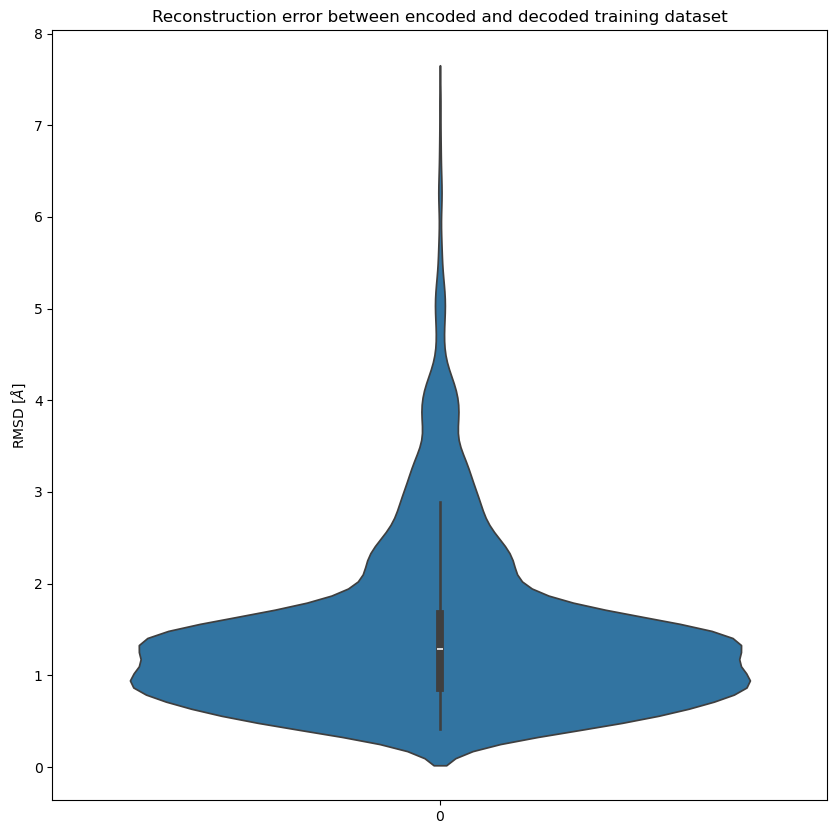

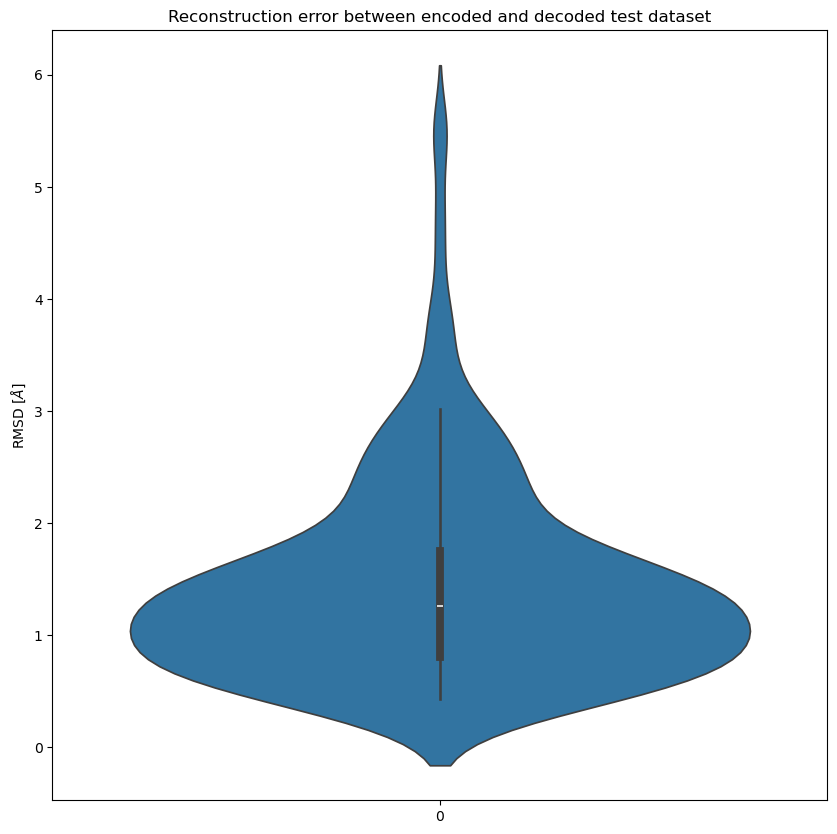

In [19]:

data = [err_train]
f = plt.figure(figsize=(10, 10))
sns.violinplot(data)
plt.ylabel('RMSD [$\AA$]')
plt.title('Reconstruction error between encoded and decoded training dataset')
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.png', dpi=300)

data = [err_test]
f = plt.figure(figsize=(10, 10))
sns.violinplot(data)
plt.ylabel('RMSD [$\AA$]')
plt.title('Reconstruction error between encoded and decoded test dataset')
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.png', dpi=300)

Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5FWK_K.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/5FWK_K.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5TTU_A.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/5TTU_A.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/3LXL_A.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/3LXL_A.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5NKE_A.pdb -> Results/run_trial_BRAFActivationLoop_postalign_clea

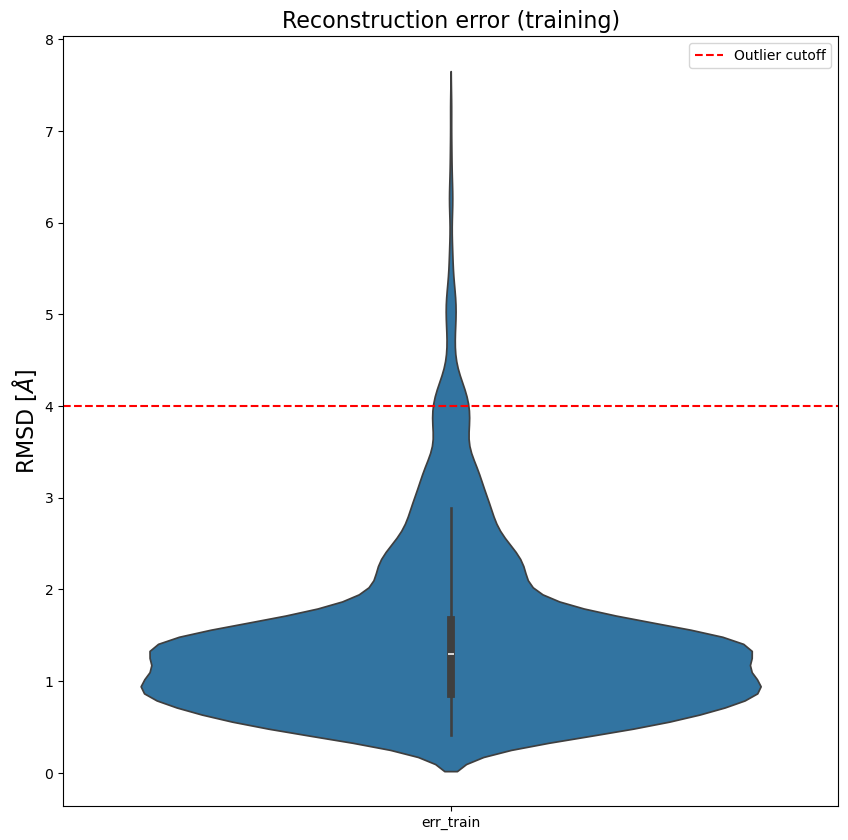

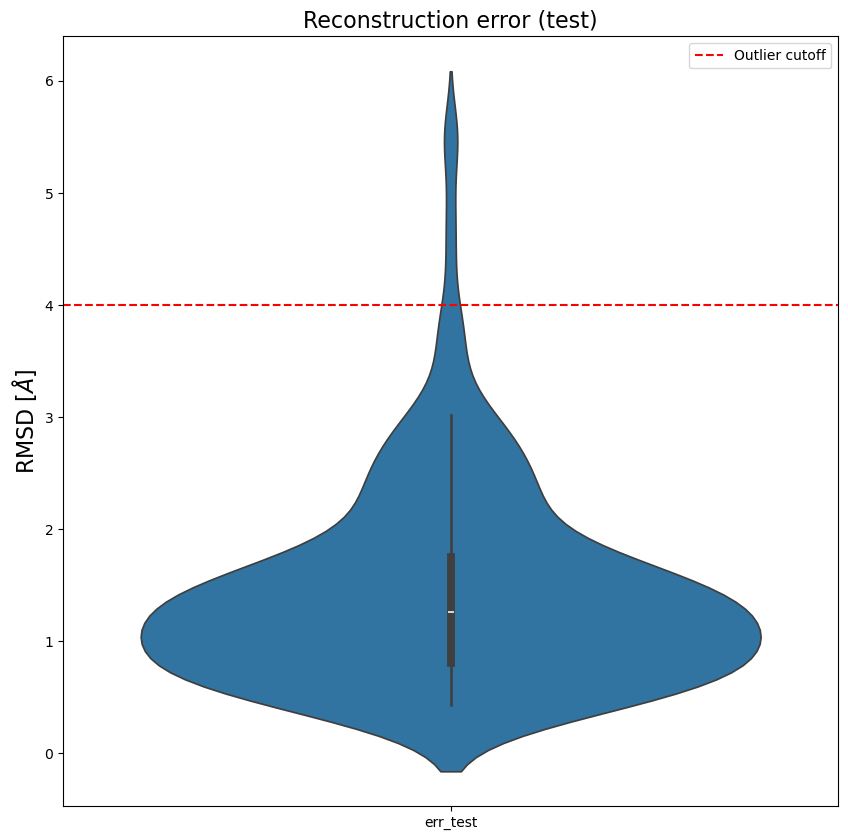

In [20]:
"""
This script filters out PDB structures with reconstruction errors above a 4 Å RMSD threshold, copies them into separate outlier folders for training and test sets, and visualizes the error distributions using violin plots.

"""
saveName = '_foldingnet_checkpoint'
train_err_csv = f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv'
test_err_csv = f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv'

# Load reconstruction errors from CSV
df_err_train = pd.read_csv(train_err_csv)   
df_err_test = pd.read_csv(test_err_csv)  

#Identify outlier indices with RMSD > 4
train_outlier_indices = df_err_train.index[df_err_train['err_train'] > 4].to_list()
test_outlier_indices = df_err_test.index[df_err_test['err_test'] > 4].to_list()

#Get sorted list of original PDB filenames
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

#Create directories to store outlier PDB files
outlier_dir_train = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train'
outlier_dir_test = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_test'
os.makedirs(outlier_dir_train, exist_ok=True)
os.makedirs(outlier_dir_test, exist_ok=True)

#Copy training outliers into designated folder
source_dir_train = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train'
for row_i in train_outlier_indices:
    frame_idx = train_indices[row_i]          
    original_filename = files[frame_idx]     

    src = os.path.join(source_dir_train, original_filename)
    dst = os.path.join(outlier_dir_train, original_filename)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied outlier (train): {src} -> {dst}')
    else:
        print(f'Skipping missing file (train): {src}')

#Copy test outliers into designated folder
source_dir_test = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test'
for row_i in test_outlier_indices:
    frame_idx = test_indices[row_i]
    original_filename = files[frame_idx]

    src = os.path.join(source_dir_test, original_filename)
    dst = os.path.join(outlier_dir_test, original_filename)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied outlier (test): {src} -> {dst}')
    else:
        print(f'Skipping missing file (test): {src}')

#Plot violin plot for training reconstruction errors
f = plt.figure(figsize=(10, 10))
sns.violinplot(data=[df_err_train['err_train']])
plt.axhline(y=4.0, color='red', linestyle='--', label='Outlier cutoff')
plt.legend()
plt.ylabel('RMSD [$\\AA$]', fontsize=16)
plt.title('Reconstruction error (training)', fontsize=16)
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.png', dpi=300)

#Plot violin plot for test reconstruction errors
f = plt.figure(figsize=(10, 10))
sns.violinplot(data=[df_err_test['err_test']])
plt.axhline(y=4.0, color='red', linestyle='--', label='Outlier cutoff')
plt.legend()
plt.ylabel('RMSD [$\\AA$]', fontsize=16)
plt.title('Reconstruction error (test)', fontsize=16)
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.png', dpi=300)


In [21]:
MA.setup_grid(30)
landscape_err_latent, landscape_err_3d, xaxis, yaxis = MA.scan_error()
df_landscape_err_latent = pd.DataFrame(landscape_err_latent)
df_landscape_err_latent.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent_{saveName}.csv', index=False)

df_landscape_err_3d = pd.DataFrame(landscape_err_3d)
df_landscape_err_3d.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_3d_{saveName}.csv', index=False)

df_xaxis = pd.DataFrame(xaxis)
df_xaxis.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis_{saveName}.csv', index=False)

df_yaxis = pd.DataFrame(yaxis)
df_yaxis.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis_{saveName}.csv', index=False)

Decoding grid:   0%|          | 0/113 [00:00<?, ?it/s]

Decoding grid:   2%|▏         | 2/113 [00:00<00:07, 15.39it/s]

Decoding grid:   4%|▎         | 4/113 [00:00<00:07, 14.56it/s]

Decoding grid:   5%|▌         | 6/113 [00:00<00:07, 13.98it/s]

Decoding grid:   7%|▋         | 8/113 [00:00<00:06, 15.20it/s]

...

Decoding grid_decoded:  93%|█████████▎| 105/113 [00:06<00:00, 16.25it/s]

Decoding grid_decoded:  95%|█████████▍| 107/113 [00:06<00:00, 16.83it/s]

Decoding grid_decoded:  96%|█████████▋| 109/113 [00:06<00:00, 16.25it/s]

Decoding grid_decoded:  98%|█████████▊| 111/113 [00:06<00:00, 16.74it/s]

Decoding grid_decoded: 100%|██████████| 113/113 [00:07<00:00, 16.13it/s]

Projection into latent space.

In [22]:
with torch.no_grad():
    z = net.encode(data_train.dataset)

z_training = z.data.cpu().numpy()[:, :, 0]
df_z_train = pd.DataFrame(z_training)

df_z_train['train_index'] = train_indices

mapping_df = pd.read_csv('train_index_mapping_11_newsplit.csv') 
mapping_dict = mapping_df.set_index('train_index')['pdb_filename'].to_dict()

df_z_train['pdb_filename'] = df_z_train['train_index'].map(mapping_dict)

df_z_train.to_csv(
    f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv',
    index=False
)


In [23]:
with torch.no_grad():
    z = net.encode(data_test.dataset)

z_test = z.data.cpu().numpy()[:, :, 0]
df_z_test = pd.DataFrame(z_test)

df_z_test['test_index'] = test_indices

test_mapping_df = pd.read_csv('test_index_mapping_11_newsplit.csv') 
test_mapping_dict = test_mapping_df.set_index('valid_index')['pdb_filename'].to_dict()

df_z_test['pdb_filename'] = df_z_test['test_index'].map(test_mapping_dict)

df_z_test.to_csv(
    f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv',
    index=False
)

Train: 2124 / 2124
Test: 236 / 236


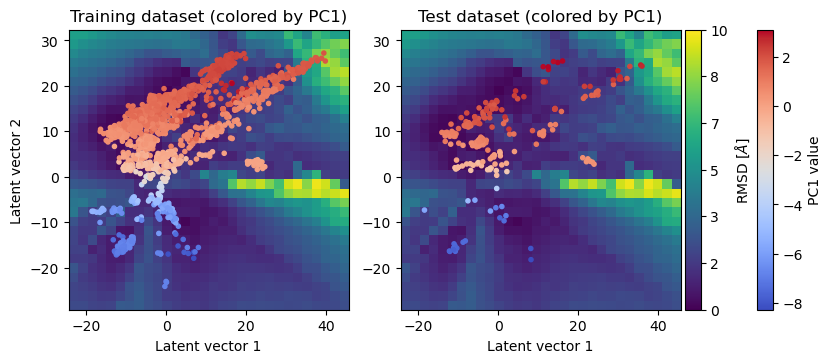

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Load precomputed latent space RMSD landscape (X, Y grid and Z values)
x_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis__foldingnet_checkpoint.csv")
y_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis__foldingnet_checkpoint.csv")
z_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent__foldingnet_checkpoint.csv")

df_x = [pd.read_csv(file, header=None).to_numpy() for file in x_file]
df_y = [pd.read_csv(file, header=None).to_numpy() for file in y_file]
df_z = [pd.read_csv(file).to_numpy() for file in z_file]

df_z=np.squeeze(np.fliplr(df_z))

# Load PC1 values for each structure
pca_df = pd.read_csv(
    'pc1_ends_noOutliers.txt',
    delim_whitespace=True,
    comment='#',
    header=None,
    names=['PC1_value', 'pdb_filename']
)

pca_df['pdb_filename'] = pca_df['pdb_filename'].str.replace('.pdb', '', regex=False)

# Load latent coordinates and clean filenames
latent_train = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv'
)
latent_test = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv'
)

latent_train['pdb_filename'] = latent_train['pdb_filename'].str.replace('.pdb', '', regex=False)
latent_test['pdb_filename'] = latent_test['pdb_filename'].str.replace('.pdb', '', regex=False)

# Merge PC1 values into latent coordinate dataframes
merged_train = pd.merge(latent_train, pca_df, on='pdb_filename', how='inner')
merged_test = pd.merge(latent_test, pca_df, on='pdb_filename', how='inner')

print(f"Train: {len(merged_train)} / {len(latent_train)}")
print(f"Test: {len(merged_test)} / {len(latent_test)}")

# Extract coordinates and PC1 values
x_encoded_train = merged_train.iloc[:, 0]
y_encoded_train = merged_train.iloc[:, 1]
pc1_train = merged_train['PC1_value']

x_encoded_test = merged_test.iloc[:, 0]
y_encoded_test = merged_test.iloc[:, 1]
pc1_test = merged_test['PC1_value']

fig = plt.figure(figsize=(8, 8))

# Plot for training data
ax1 = fig.add_axes([0.0, 0.1, 0.35, 0.35])
ax1.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
           extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax1.scatter(x_encoded_train, y_encoded_train, c=pc1_train, marker='.', cmap='coolwarm')
ax1.set_xlabel('Latent vector 1')
ax1.set_ylabel('Latent vector 2')
ax1.set_title('Training dataset (colored by PC1)')
ax1.set_aspect('auto')  

# Plot for test data
ax2 = fig.add_axes([0.415, 0.1, 0.35, 0.35])
im = ax2.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
                extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax2.scatter(x_encoded_test, y_encoded_test, c=pc1_test, marker='.', cmap='coolwarm')
ax2.set_xlabel('Latent vector 1')
ax2.set_title('Test dataset (colored by PC1)')
ax2.set_aspect('auto')  


# RMSD colorbar
cbar_ax2 = fig.add_axes([0.77, 0.1, 0.02, 0.35])
cbar_ax2.tick_params(left=False, labelleft=False, right=True, labelright=True, labelbottom=False, bottom=False)
cbar = fig.colorbar(im, cax=cbar_ax2, label='RMSD [$\AA$]')
cbar_ticks = np.linspace(0, 10, 7)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'{tick:.0f}' for tick in cbar_ticks])

# PC1 colorbar
cbar_ax_pca = fig.add_axes([0.86, 0.1, 0.02, 0.35])
pca_norm = plt.Normalize(vmin=min(pc1_train.min(), pc1_test.min()),
                         vmax=max(pc1_train.max(), pc1_test.max()))
cbar_pca = fig.colorbar(
    plt.cm.ScalarMappable(norm=pca_norm, cmap='coolwarm'),
    cax=cbar_ax_pca,
    label='PC1 value'
)

plt.savefig(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/RMSDlandscapesOnePlot_coloredByPC1.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

Train匹配数量: 2124 / 2124
Test匹配数量: 236 / 236


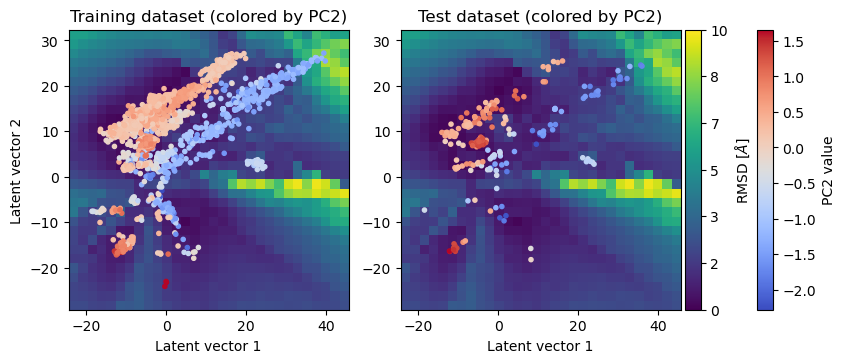

In [25]:
"""
Same as before but using PC2 to color the points 
"""
import pandas as pd
import matplotlib.pyplot as plt
import glob

x_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis__foldingnet_checkpoint.csv")
y_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis__foldingnet_checkpoint.csv")
z_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent__foldingnet_checkpoint.csv")

df_x = [pd.read_csv(file, header=None).to_numpy() for file in x_file]
df_y = [pd.read_csv(file, header=None).to_numpy() for file in y_file]
df_z = [pd.read_csv(file).to_numpy() for file in z_file]

df_z=np.squeeze(np.fliplr(df_z))

pca_df = pd.read_csv(
    'pc2_ends_noOutliers.txt',
    delim_whitespace=True,
    comment='#',
    header=None,
    names=['PC1_value', 'pdb_filename']
)

pca_df['pdb_filename'] = pca_df['pdb_filename'].str.replace('.pdb', '', regex=False)

latent_train = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv'
)
latent_test = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv'
)

latent_train['pdb_filename'] = latent_train['pdb_filename'].str.replace('.pdb', '', regex=False)
latent_test['pdb_filename'] = latent_test['pdb_filename'].str.replace('.pdb', '', regex=False)

merged_train = pd.merge(latent_train, pca_df, on='pdb_filename', how='inner')
merged_test = pd.merge(latent_test, pca_df, on='pdb_filename', how='inner')

print(f"Train匹配数量: {len(merged_train)} / {len(latent_train)}")
print(f"Test匹配数量: {len(merged_test)} / {len(latent_test)}")

x_encoded_train = merged_train.iloc[:, 0]
y_encoded_train = merged_train.iloc[:, 1]
pc1_train = merged_train['PC1_value']

x_encoded_test = merged_test.iloc[:, 0]
y_encoded_test = merged_test.iloc[:, 1]
pc1_test = merged_test['PC1_value']

fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_axes([0.0, 0.1, 0.35, 0.35])
ax1.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
           extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax1.scatter(x_encoded_train, y_encoded_train, c=pc1_train, marker='.', cmap='coolwarm')
ax1.set_xlabel('Latent vector 1')
ax1.set_ylabel('Latent vector 2')
ax1.set_title('Training dataset (colored by PC2)')
ax1.set_aspect('auto')  

ax2 = fig.add_axes([0.415, 0.1, 0.35, 0.35])
im = ax2.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
                extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax2.scatter(x_encoded_test, y_encoded_test, c=pc1_test, marker='.', cmap='coolwarm')
ax2.set_xlabel('Latent vector 1')
ax2.set_title('Test dataset (colored by PC2)')
ax2.set_aspect('auto')  

cbar_ax2 = fig.add_axes([0.77, 0.1, 0.02, 0.35])
cbar_ax2.tick_params(left=False, labelleft=False, right=True, labelright=True, labelbottom=False, bottom=False)
cbar = fig.colorbar(im, cax=cbar_ax2, label='RMSD [$\AA$]')
cbar_ticks = np.linspace(0, 10, 7)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'{tick:.0f}' for tick in cbar_ticks])

cbar_ax_pca = fig.add_axes([0.86, 0.1, 0.02, 0.35])
pca_norm = plt.Normalize(vmin=min(pc1_train.min(), pc1_test.min()),
                         vmax=max(pc1_train.max(), pc1_test.max()))
cbar_pca = fig.colorbar(
    plt.cm.ScalarMappable(norm=pca_norm, cmap='coolwarm'),
    cax=cbar_ax_pca,
    label='PC2 value'
)

plt.savefig(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/RMSDlandscapesOnePlot_coloredByPC2.png',
    dpi=300, bbox_inches='tight'
)
plt.show()